## 1. Chuẩn bị thư viện và đường dẫn



In [1]:
from pathlib import Path
import json
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

CONFIG_PATH = ROOT / "configs" / "benchmark_models.yaml"
VECTOR_DIR = ROOT / "data" / "vector_store"
QDRANT_PATH = ROOT / "data" / "qdrant_db"
RETRIEVAL_DIR = ROOT / "results" / "retrieval_benchmark"
EVAL_DIR = ROOT / "results" / "generated_qa_30"

print("ROOT:", ROOT)
print("VECTOR_DIR:", VECTOR_DIR.relative_to(ROOT))
print("QDRANT_PATH:", QDRANT_PATH.relative_to(ROOT))

ROOT: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep
VECTOR_DIR: data/vector_store
QDRANT_PATH: data/qdrant_db


## 2. Danh sách embedding model và collection Qdrant

Bảng dưới đây đọc từ `configs/benchmark_models.yaml`. Mỗi embedding model có một `collection_name` riêng trong Qdrant để có thể benchmark độc lập.

In [2]:
try:
    import yaml
except ImportError as exc:
    raise SystemExit("Cần cài PyYAML để đọc configs/benchmark_models.yaml") from exc

config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
model_rows = []
for item in config["models"]:
    model_rows.append({
        "alias": item["alias"],
        "model_name": item["model_name"],
        "collection_name": item["collection_name"],
        "batch_size": item.get("batch_size"),
        "max_length": item.get("max_length"),
    })

models_df = pd.DataFrame(model_rows)
display(models_df)

,alias,model_name,collection_name,batch_size,max_length
0,sup-simcse-vietnamese-phobert-base,VoVanPhuc/sup-SimCSE-VietNamese-phobert-base,thuoc_metadata_sup_simcse,8,256
1,vietnamese-bi-encoder,bkai-foundation-models/vietnamese-bi-encoder,thuoc_metadata_vietnamese_bi_encoder,16,256
2,bge-m3,BAAI/bge-m3,thuoc_metadata_bge_m3,16,8192
3,multilingual-e5-base,intfloat/multilingual-e5-base,thuoc_metadata_multilingual_e5_base,16,512


## 3. Kiểm tra các file vector JSONL đã xuất

Sau khi vector được lưu trong Qdrant, project xuất thêm vector ra `data/vector_store/*.jsonl` để dễ kiểm tra và minh họa trong báo cáo. Mỗi dòng JSONL tương ứng với một chunk đã được embedding.

In [3]:
vector_file_map = {
    "sup-simcse-vietnamese-phobert-base": "embeddings_sup_simcse_vietnamese_phobert_base.jsonl",
    "vietnamese-bi-encoder": "embeddings_vietnamese_bi_encoder.jsonl",
    "bge-m3": "embeddings_baai__bge_m3.jsonl",
    "multilingual-e5-base": "embeddings_multilingual_e5_base.jsonl",
}

vector_rows = []
for alias, filename in vector_file_map.items():
    path = VECTOR_DIR / filename
    line_count = 0
    first_obj = None
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            for line_count, line in enumerate(f, start=1):
                if first_obj is None:
                    first_obj = json.loads(line)
    vector = first_obj.get("vector", []) if first_obj else []
    payload = first_obj.get("payload", {}) if first_obj else {}
    vector_rows.append({
        "alias": alias,
        "file": filename,
        "so_vector": line_count,
        "kich_thuoc_vector": len(vector),
        "vi_du_product_id": payload.get("product_id", ""),
        "vi_du_ten_san_pham": payload.get("ten_san_pham", ""),
        "dung_luong_MB": round(path.stat().st_size / (1024 * 1024), 2) if path.exists() else 0,
    })

vectors_df = pd.DataFrame(vector_rows)
display(vectors_df)

,alias,file,so_vector,kich_thuoc_vector,vi_du_product_id,vi_du_ten_san_pham,dung_luong_MB
0,sup-simcse-vietnamese-phobert-base,embeddings_sup_simcse_vietnamese_phobert_base....,1000,768,sp190,PHÂN BÓN LÁ CHỐNG VÀNG LÁ,17.53
1,vietnamese-bi-encoder,embeddings_vietnamese_bi_encoder.jsonl,1000,768,sp289,CANXI MAGIE BO DẠNG BỘT,17.54
2,bge-m3,embeddings_baai__bge_m3.jsonl,1000,1024,sp142,DẦU KHOÁNG 99EC,23.03
3,multilingual-e5-base,embeddings_multilingual_e5_base.jsonl,1000,768,sp137,CARTAP HYDROCHLORIDE 95SP,17.52


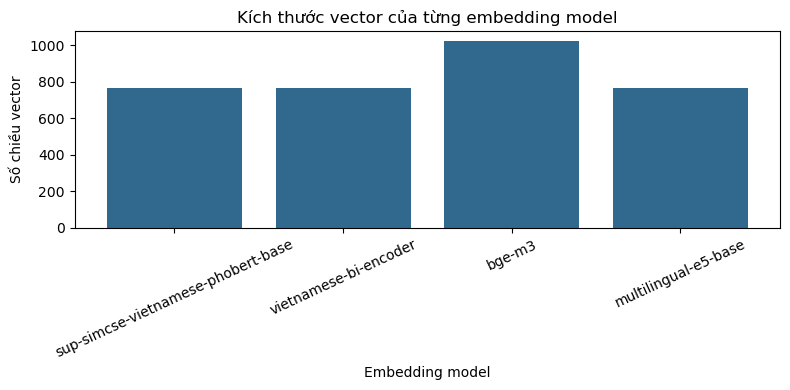

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vectors_df["alias"], vectors_df["kich_thuoc_vector"], color="#31688e")
ax.set_title("Kích thước vector của từng embedding model")
ax.set_xlabel("Embedding model")
ax.set_ylabel("Số chiều vector")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 4. Kiểm tra collection trong Qdrant

Bảng này kiểm tra trực tiếp Qdrant local. Nếu mỗi collection có 1000 points thì nghĩa là toàn bộ 1000 chunks đã được lưu vector đầy đủ cho model đó.

In [5]:
try:
    from qdrant_client import QdrantClient
except ImportError as exc:
    raise SystemExit("Cần cài qdrant-client để kiểm tra Qdrant") from exc

client = QdrantClient(path=str(QDRANT_PATH))
qdrant_rows = []
for row in model_rows:
    collection_name = row["collection_name"]
    info = client.get_collection(collection_name)
    qdrant_rows.append({
        "alias": row["alias"],
        "collection_name": collection_name,
        "points_count": info.points_count,
        "vector_size": info.config.params.vectors.size,
        "distance": str(info.config.params.vectors.distance),
    })
client.close()

qdrant_df = pd.DataFrame(qdrant_rows)
display(qdrant_df)

,alias,collection_name,points_count,vector_size,distance
0,sup-simcse-vietnamese-phobert-base,thuoc_metadata_sup_simcse,1000,768,Cosine
1,vietnamese-bi-encoder,thuoc_metadata_vietnamese_bi_encoder,1000,768,Cosine
2,bge-m3,thuoc_metadata_bge_m3,1000,1024,Cosine
3,multilingual-e5-base,thuoc_metadata_multilingual_e5_base,1000,768,Cosine


## 5. So sánh kết quả retrieval-only

Phần này đọc kết quả từ `results/retrieval_benchmark`. Đây là benchmark chỉ kiểm tra bước truy xuất vector, chưa gọi LLM.

In [6]:
retrieval_name_map = {
    "bge_m3": "bge-m3",
    "multilingual_e5_base": "multilingual-e5-base",
    "sup_simcse": "sup-simcse-vietnamese-phobert-base",
    "vietnamese_bi_encoder": "vietnamese-bi-encoder",
}

retrieval_rows = []
for path in sorted(RETRIEVAL_DIR.glob("*.json")):
    items = json.loads(path.read_text(encoding="utf-8"))
    latencies = []
    top1_scores = []
    for item in items:
        if isinstance(item.get("latency_seconds"), (int, float)):
            latencies.append(item["latency_seconds"])
        chunks = item.get("retrieved_chunks", [])
        if chunks and isinstance(chunks[0].get("score"), (int, float)):
            top1_scores.append(chunks[0]["score"])

    stem = path.stem
    retrieval_rows.append({
        "alias": retrieval_name_map.get(stem, stem),
        "so_cau": len(items),
        "latency_tb_s": sum(latencies) / len(latencies) if latencies else None,
        "top1_score_tb": sum(top1_scores) / len(top1_scores) if top1_scores else None,
    })

retrieval_df = pd.DataFrame(retrieval_rows).sort_values("top1_score_tb", ascending=False)
display(retrieval_df)

,alias,so_cau,latency_tb_s,top1_score_tb
1,multilingual-e5-base,18,0.015539,0.871443
2,sup-simcse-vietnamese-phobert-base,18,0.027661,0.779249
0,bge-m3,18,0.025444,0.700680
3,vietnamese-bi-encoder,18,0.015583,0.476994


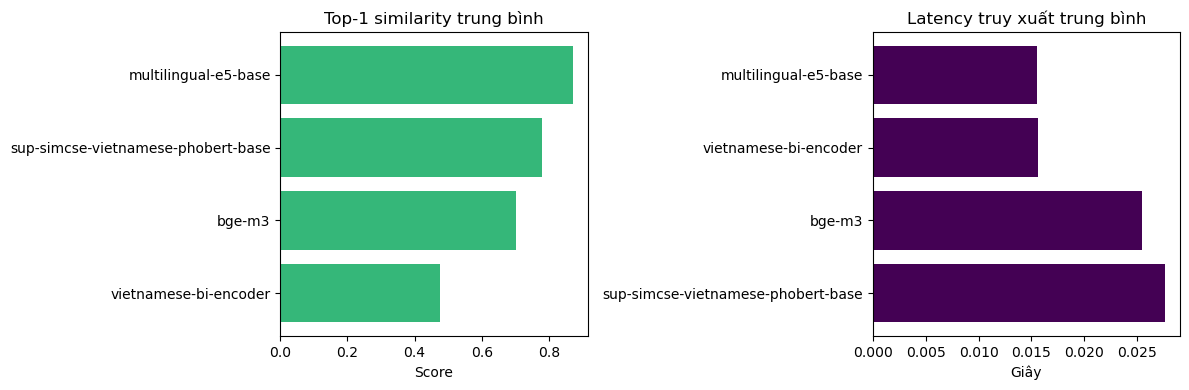

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = retrieval_df.sort_values("top1_score_tb")
axes[0].barh(plot_df["alias"], plot_df["top1_score_tb"], color="#35b779")
axes[0].set_title("Top-1 similarity trung bình")
axes[0].set_xlabel("Score")

plot_df = retrieval_df.sort_values("latency_tb_s", ascending=False)
axes[1].barh(plot_df["alias"], plot_df["latency_tb_s"], color="#440154")
axes[1].set_title("Latency truy xuất trung bình")
axes[1].set_xlabel("Giây")

plt.tight_layout()
plt.show()

## 6. So sánh kết quả trên bộ 30 câu hỏi


Phần này đọc các file `eval_*.json` trong `results/generated_qa_30`. Mỗi embedding được so sánh trên 2 LLM khác nhau.

In [8]:
eval_rows = []
for path in sorted(EVAL_DIR.glob("eval_*.json")):
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = data.get("summary", data)
    pipeline = path.stem.replace("eval_", "")
    llm, embedding = pipeline.split("__", 1)
    eval_rows.append({
        "pipeline": pipeline,
        "llm": llm,
        "embedding": embedding,
        "total": summary["total"],
        "passed": summary["passed"],
        "pass_rate": summary["pass_rate"],
        "retrieval_hit_rate": summary["retrieval_hit_rate"],
        "answer_keyword_hit_rate": summary["answer_keyword_hit_rate"],
        "answer_product_name_hit_rate": summary["answer_product_name_hit_rate"],
    })

eval_df = pd.DataFrame(eval_rows).sort_values("pass_rate", ascending=False)
display(eval_df)

,pipeline,llm,embedding,total,passed,pass_rate,retrieval_hit_rate,answer_keyword_hit_rate,answer_product_name_hit_rate
4,qwen3_4b__bge_m3,qwen3_4b,bge_m3,30,28,0.9333,0.9333,0.9667,0.9333
0,qwen25_3b__bge_m3,qwen25_3b,bge_m3,30,26,0.8667,0.9333,0.9000,0.8667
5,qwen3_4b__multilingual_e5_base,qwen3_4b,multilingual_e5_base,30,22,0.7333,0.7333,0.9333,0.8333
1,qwen25_3b__multilingual_e5_base,qwen25_3b,multilingual_e5_base,30,20,0.6667,0.7333,0.8333,0.7333
7,qwen3_4b__vietnamese_bi_encoder,qwen3_4b,vietnamese_bi_encoder,30,12,0.4000,0.4000,0.8000,0.7667
3,qwen25_3b__vietnamese_bi_encoder,qwen25_3b,vietnamese_bi_encoder,30,11,0.3667,0.4000,0.8000,0.7000
2,qwen25_3b__sup_simcse,qwen25_3b,sup_simcse,30,4,0.1333,0.1333,0.8667,0.7333
6,qwen3_4b__sup_simcse,qwen3_4b,sup_simcse,30,4,0.1333,0.1333,0.8333,0.7667


llm,qwen25_3b,qwen3_4b
embedding,,
bge_m3,0.8667,0.9333
multilingual_e5_base,0.6667,0.7333
sup_simcse,0.1333,0.1333
vietnamese_bi_encoder,0.3667,0.4000


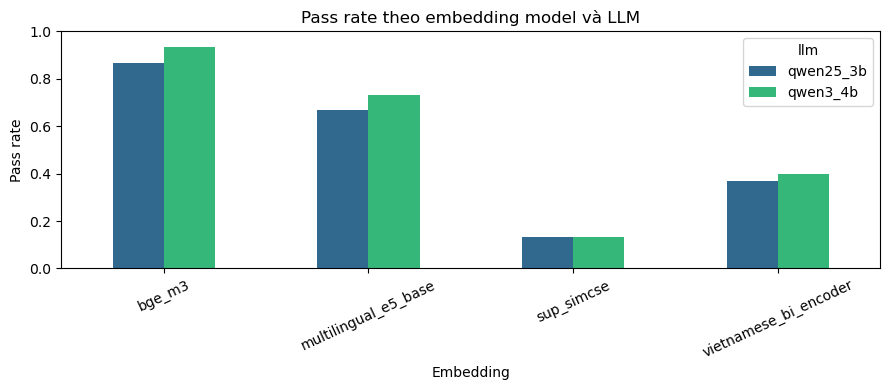

In [9]:
pivot = eval_df.pivot(index="embedding", columns="llm", values="pass_rate").sort_index()
display(pivot)

ax = pivot.plot(kind="bar", figsize=(9, 4), color=["#31688e", "#35b779"])
ax.set_title("Pass rate theo embedding model và LLM")
ax.set_xlabel("Embedding")
ax.set_ylabel("Pass rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 7. Nhận xét tổng hợp

- `BGE-M3` có vector 1024 chiều, lớn hơn 3 model còn lại. Trong bộ `generated_qa_30`, BGE-M3 cho kết quả tốt nhất khi kết hợp với cả Qwen2.5-3B và Qwen3-4B.
- `Multilingual-E5-base` có điểm retrieval-only top-1 cao trong bộ benchmark 18 câu, nhưng kết quả QA cuối cùng thấp hơn BGE-M3. Điều này cho thấy score retrieval không phải lúc nào cũng tương đương chất lượng trả lời cuối cùng.
- `Sup-SimCSE Vietnamese PhoBERT` là model tiếng Việt, nhưng trong bộ generated QA hiện tại retrieval hit thấp hơn, làm pass rate toàn pipeline thấp.
- `Vietnamese Bi-Encoder` có tốc độ truy xuất nhanh và vector 768 chiều, nhưng chất lượng truy xuất trong bộ đánh giá hiện tại chưa tốt bằng BGE-M3.

Kết luận thực nghiệm hiện tại: nếu ưu tiên chất lượng trên bộ `generated_qa_30`, embedding phù hợp nhất là `BGE-M3`. Nếu cần phân tích thêm, nên mở rộng bộ câu hỏi đánh giá và gán nhãn expected product kỹ hơn.